# Dataset Construction — FictiPay top-88 Feature Matrix

Builds one row per account from the raw KYC, transaction and day-end balance tables, ranks features by SHAP importance across a LightGBM/XGBoost/CatBoost ensemble, and exports the 88 features used by every model in the project.

**Observation window:** 2024-01-01 to 2024-03-31. **Label:** `CHURN`, April inactivity, supplied in `train_labels.csv`.

**Outputs**

| File | Consumed by |
|---|---|
| `account_features_train_top88.csv` — 595,000 accounts | `data_loader.py` |
| `account_features_test_top88.csv` — 255,000 accounts, unlabelled | `data_loader.py` |
| `march_split_native_numeric_features_for_dec.parquet` — 191 numeric features | `dec-pipeline.ipynb` |

**Feature selection is frozen.** Step 8 exports a fixed list rather than the ranking recomputed in step 7, so re-running reproduces the same dataset; any divergence is reported rather than applied.

**Environment.** Kaggle GPU (RAPIDS cuDF).

## 1 · Environment

RAPIDS cuDF with a single dask-cuda worker. The cell also patches a dask-cuda incompatibility present on the Kaggle image.

In [1]:
# ============================================================
# XMV-Net dataset build — SETUP. Restart kernel ONCE, then run this cell.
# Self-heals dask_cuda 26.2 vs cuda-core incompatibility.
# ============================================================
import subprocess, sys, types, pathlib

subprocess.run([sys.executable, "-m", "pip", "install", "--force-reinstall",
                "--no-deps", "-q", "dask-cuda==26.2.0"], check=False)

init_path = pathlib.Path("/usr/local/lib/python3.12/dist-packages/dask_cuda/initialize.py")
src = init_path.read_text()
if "# DASKCUDA_PATCHED" not in src:
    shim = (
        "try:\n"
        "    import cuda.core.experimental\n"
        "except ModuleNotFoundError:\n"
        "    import types as _t, sys as _s\n"
        "    import cuda.core\n"
        "    _cc = cuda.core\n"
        "    _e = _t.ModuleType('cuda.core.experimental')\n"
        "    for _k, _v in vars(_cc).items():\n"
        "        setattr(_e, _k, _v)\n"
        "    class _Device:\n"
        "        def set_current(self):\n"
        "            import numba.cuda; numba.cuda.select_device(0)\n"
        "    _e.Device = _Device\n"
        "    _s.modules['cuda.core.experimental'] = _e\n"
        "    _cc.experimental = _e\n"
        "# DASKCUDA_PATCHED"
    )
    src = src.replace("import cuda.core.experimental", shim, 1)
    init_path.write_text(src)
    print("Patched dask_cuda/initialize.py")
else:
    print("dask_cuda already patched")

# --- FIXED: try the real cuda.core.experimental first; only fake it if it
# genuinely doesn't exist. The old hasattr() check gave false negatives and
# clobbered a working experimental module with an incomplete fake one,
# which broke numba_cuda's later `from cuda.core.experimental import Program`.
try:
    import cuda.core.experimental  # works fine on current image — leave it alone
except ModuleNotFoundError:
    import cuda.core as _cc
    _e = types.ModuleType("cuda.core.experimental")
    for _k, _v in vars(_cc).items():
        setattr(_e, _k, _v)
    class _Device:
        def set_current(self):
            import numba.cuda; numba.cuda.select_device(0)
    _e.Device = _Device
    sys.modules["cuda.core.experimental"] = _e
    _cc.experimental = _e

for _m in [k for k in list(sys.modules) if k.startswith("dask_cuda")]:
    del sys.modules[_m]

import numpy as np, pandas as pd, gc, warnings
warnings.filterwarnings("ignore")
import cudf, dask_cudf
from dask_cuda import LocalCUDACluster
from dask.distributed import Client
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import rankdata
print("imports OK — cudf", cudf.__version__, "| lgb", lgb.__version__, "| xgb", xgb.__version__)
SEED = 42
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.2/160.2 kB 1.5 MB/s eta 0:00:00
Patched dask_cuda/initialize.py
imports OK — cudf 26.02.01 | lgb 4.6.0 | xgb 3.2.0


In [2]:
# dask-CUDA cluster
cluster = LocalCUDACluster(n_workers=1, device_memory_limit="12GB",
                           rmm_managed_memory=True, rmm_pool_size="10GB")
client = Client(cluster)
client


Connection method: Cluster object,Cluster type: dask_cuda.LocalCUDACluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 1
Total threads: 1,Total memory: 30.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42731,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:43705,Total threads: 1
Dashboard: http://127.0.0.1:43991/status,Memory: 30.00 GiB
Nanny: tcp://127.0.0.1:43983,


In [3]:
# constants
BASE       = "/kaggle/input/competitions/bkash-presents-nsucec-datathon/public"
TRX_PATH   = f"{BASE}/transactions/trx_2024-0*.parquet"
BAL_PATH   = f"{BASE}/dayend_balance/balance_2024-0*.parquet"
KYC_PATH   = f"{BASE}/kyc.parquet"
TRAIN_PATH = f"{BASE}/train_labels.csv"
TEST_PATH  = f"{BASE}/test.csv"
SUB_PATH   = f"{BASE}/sample_submission.csv"

# FIXED - use cudf-compatible datetime
REF_DATE  = "2024-03-31"
OBS_START = "2024-01-01"
APRIL_1   = "2024-04-01"

# Also add these for later use with numpy operations
REF_DATE_NP  = np.datetime64(REF_DATE, "ns")
OBS_START_NP = np.datetime64(OBS_START, "ns")
APRIL_1_NP   = np.datetime64(APRIL_1, "ns")
AMT_CAP   = 200_000
BLOCKSIZE = "256MB"

def flatten_agg_columns(df):
    df.columns = [f"{a}_{b}" if b else str(a) for a, b in df.columns]
    return df


## 2 · Raw-data audits

Confirms that train and test account IDs are unique and disjoint, and that no transaction or balance row falls on or after 2024-04-01.

In [4]:
# ID OVERLAP CHECK — train_labels.csv vs test.csv
tr = pd.read_csv(TRAIN_PATH, usecols=["ACCOUNT_ID"])
te = pd.read_csv(TEST_PATH,  usecols=["ACCOUNT_ID"])

tr_ids = set(tr["ACCOUNT_ID"].astype(str))
te_ids = set(te["ACCOUNT_ID"].astype(str))
overlap = tr_ids & te_ids

print("train rows:", len(tr), "| unique IDs:", len(tr_ids),
      "| dupes within train:", len(tr) - len(tr_ids))
print("test  rows:", len(te), "| unique IDs:", len(te_ids),
      "| dupes within test: ", len(te) - len(te_ids))
print("\nOVERLAPPING IDs:", len(overlap))

if overlap:
    print("!! train and test are NOT disjoint")
    print("   sample:", list(overlap)[:10])
    print("   overlap as % of test:", round(100 * len(overlap) / len(te_ids), 3), "%")
else:
    print("OK — train and test ID sets are disjoint")

# sanity: does the sample submission match test.csv exactly?
sub = pd.read_csv(SUB_PATH, usecols=["ACCOUNT_ID"])
sub_ids = set(sub["ACCOUNT_ID"].astype(str))
print("\nsample_submission IDs:", len(sub_ids),
      "| identical to test.csv:", sub_ids == te_ids)

train rows: 595000 | unique IDs: 595000 | dupes within train: 0
test  rows: 255000 | unique IDs: 255000 | dupes within test:  0

OVERLAPPING IDs: 0
OK — train and test ID sets are disjoint

sample_submission IDs: 255000 | identical to test.csv: True


In [5]:
# DATE AUDIT — unique dates present in transactions, balances, KYC
import glob, gc

# --- transactions (TRX_DATETIME) — read one file at a time, dedupe per file ---
trx_dates = set()
for f in sorted(glob.glob(TRX_PATH)):
    d = cudf.read_parquet(f, columns=["TRX_DATETIME"])["TRX_DATETIME"]
    u = cudf.to_datetime(d).dt.floor("D").unique().to_pandas()
    trx_dates.update(u.tolist())
    print(f"  {f.split('/')[-1]}: {len(u)} unique days")
    del d, u; gc.collect()

trx_dates = sorted(trx_dates)
print(f"\nTRANSACTIONS — {len(trx_dates)} unique dates")
print(f"  min: {trx_dates[0].date()}   max: {trx_dates[-1].date()}")
for dt in trx_dates:
    print("   ", dt.date())

# --- day-end balances (DATE) ---
bal_dates = set()
for f in sorted(glob.glob(BAL_PATH)):
    d = cudf.read_parquet(f, columns=["DATE"])["DATE"]
    u = cudf.to_datetime(d).dt.floor("D").unique().to_pandas()
    bal_dates.update(u.tolist())
    print(f"  {f.split('/')[-1]}: {len(u)} unique days")
    del d, u; gc.collect()

bal_dates = sorted(bal_dates)
print(f"\nBALANCES — {len(bal_dates)} unique dates")
print(f"  min: {bal_dates[0].date()}   max: {bal_dates[-1].date()}")
for dt in bal_dates:
    print("   ", dt.date())

# --- KYC (ACCOUNT_OPEN_DATE) — likely thousands of values, so summarise ---
kyc_d = cudf.read_parquet(KYC_PATH, columns=["ACCOUNT_OPEN_DATE"])["ACCOUNT_OPEN_DATE"]
kyc_u = cudf.to_datetime(kyc_d).dt.floor("D").unique().to_pandas().sort_values()
print(f"\nKYC ACCOUNT_OPEN_DATE — {len(kyc_u)} unique dates")
print(f"  min: {kyc_u.iloc[0].date()}   max: {kyc_u.iloc[-1].date()}")
print("  first 10:", [str(x.date()) for x in kyc_u.head(10)])
print("  last 10: ", [str(x.date()) for x in kyc_u.tail(10)])
# uncomment to dump all:
# for dt in kyc_u: print("   ", dt.date())

# --- the check that matters ---
print("\n--- APRIL LEAK CHECK ---")
print("any trx  >= 2024-04-01:", any(str(d.date()) >= "2024-04-01" for d in trx_dates))
print("any bal  >= 2024-04-01:", any(str(d.date()) >= "2024-04-01" for d in bal_dates))

  trx_2024-01.parquet: 31 unique days
  trx_2024-02.parquet: 29 unique days
  trx_2024-03.parquet: 31 unique days

TRANSACTIONS — 91 unique dates
  min: 2024-01-01   max: 2024-03-31
    2024-01-01
    2024-01-02
    2024-01-03
    2024-01-04
    2024-01-05
    2024-01-06
    2024-01-07
    2024-01-08
    2024-01-09
    2024-01-10
    2024-01-11
    2024-01-12
    2024-01-13
    2024-01-14
    2024-01-15
    2024-01-16
    2024-01-17
    2024-01-18
    2024-01-19
    2024-01-20
    2024-01-21
    2024-01-22
    2024-01-23
    2024-01-24
    2024-01-25
    2024-01-26
    2024-01-27
    2024-01-28
    2024-01-29
    2024-01-30
    2024-01-31
    2024-02-01
    2024-02-02
    2024-02-03
    2024-02-04
    2024-02-05
    2024-02-06
    2024-02-07
    2024-02-08
    2024-02-09
    2024-02-10
    2024-02-11
    2024-02-12
    2024-02-13
    2024-02-14
    2024-02-15
    2024-02-16
    2024-02-17
    2024-02-18
    2024-02-19
    2024-02-20
    2024-02-21
    2024-02-22
    2024-02-23
    2024

## 3 · Per-account aggregation


In [5]:
# IDs + KYC with corrected tenure buckets (90/180/365/730)
def load_ids():
    train = cudf.read_csv(TRAIN_PATH)
    test  = cudf.read_csv(TEST_PATH)
    all_ids = cudf.concat([train["ACCOUNT_ID"], test["ACCOUNT_ID"]]).unique()
    return train, test, all_ids

def load_kyc_gpu(all_ids):
    kyc = cudf.read_parquet(KYC_PATH)
    kyc = kyc[kyc["ACCOUNT_ID"].isin(all_ids)]
    kyc["ACCOUNT_OPEN_DATE"] = cudf.to_datetime(kyc["ACCOUNT_OPEN_DATE"])
    t = (REF_DATE - kyc["ACCOUNT_OPEN_DATE"]).dt.days
    kyc["tenure_days"]     = t
    kyc["tenure_0_90d"]    = (t <= 90).astype("int8")
    kyc["tenure_91_180d"]  = ((t >= 91)  & (t <= 180)).astype("int8")   # EDA: 100% churn (tiny bucket)
    kyc["tenure_181_365d"] = ((t >= 181) & (t <= 365)).astype("int8")   # EDA: 7.76% churn (low)
    kyc["tenure_1_2y"]     = ((t >= 366) & (t <= 730)).astype("int8")   # EDA: 12.98%
    kyc["tenure_2y_plus"]  = (t > 730).astype("int8")                   # EDA: 12.67%
    kyc["GENDER"] = kyc["GENDER"].fillna("Unknown")
    kyc["REGION"] = kyc["REGION"].fillna("Unknown")
    keep = ["ACCOUNT_ID","GENDER","REGION","tenure_days","tenure_0_90d",
            "tenure_91_180d","tenure_181_365d","tenure_1_2y","tenure_2y_plus"]
    return kyc[keep]


In [6]:
# multi-window transaction aggregates (7/14/30/60/90d) + salary/weekend/momentum
def aggregate_transactions_gpu(all_ids):
    trx = dask_cudf.read_parquet(
        TRX_PATH,
        columns=["TRX_DATETIME","SRC_ACCOUNT","DST_ACCOUNT","TRX_TYPE","TRX_AMT"],
        blocksize=BLOCKSIZE,
    )
    trx = trx[trx["SRC_ACCOUNT"].isin(all_ids)]
    trx["TRX_DATETIME"] = trx["TRX_DATETIME"].map_partitions(
        cudf.to_datetime, meta=cudf.Series([], name="TRX_DATETIME", dtype="datetime64[ns]"))
    trx = trx[(trx["TRX_DATETIME"] >= OBS_START) & (trx["TRX_DATETIME"] < APRIL_1)]

    # one-time helper columns (single pass)
    trx["trx_date"]   = trx["TRX_DATETIME"].dt.floor("D")
    trx["dom"]        = trx["trx_date"].dt.day
    trx["dow"]        = trx["trx_date"].dt.weekday        # Mon=0 ... Sun=6
    trx["is_salary"]  = (trx["dom"] <= 3).astype("int8")  # EDA: days 1-3 carry the +32% spike
    trx["is_weekend"] = (trx["dow"] >= 5).astype("int8")
    trx["is_sunday"]  = (trx["dow"] == 6).astype("int8")
    trx["is_limit"]   = (trx["TRX_AMT"] >= AMT_CAP).astype("int8")
    trx["is_merch"]   = (trx["TRX_TYPE"] == "MerchantPay").astype("int8")
    trx["salary_amt"] = trx["TRX_AMT"] * trx["is_salary"]
    trx["month"]      = trx["trx_date"].dt.month
    # FIXED - convert cudf Series to numpy-compatible operation
    trx["days_ago"] = trx["trx_date"].map_partitions(
    lambda s: (np.datetime64(APRIL_1, "ns") - s).dt.days,
    meta=("days_ago", "int64")
    )
    
    feats = None
    for w in [7, 14, 30, 60, 90]:
        sub = trx[trx["days_ago"] < w]
        g = sub.groupby("SRC_ACCOUNT").agg({
            "TRX_AMT":["count","sum","mean"],
            "is_salary":["sum"], "salary_amt":["sum"],
            "is_weekend":["sum"], "is_sunday":["sum"], "is_limit":["sum"],
        }).compute()
        g = flatten_agg_columns(g)
        g[f"uniq_cp_{w}d"]      = sub.groupby("SRC_ACCOUNT")["DST_ACCOUNT"].nunique().compute()
        g[f"active_days_{w}d"]  = sub.groupby("SRC_ACCOUNT")["trx_date"].nunique().compute()
        g = g.rename(columns={
            "TRX_AMT_count": f"n_trx_{w}d", "TRX_AMT_sum": f"total_amt_{w}d",
            "TRX_AMT_mean": f"avg_amt_{w}d", "is_salary_sum": f"n_salary_{w}d",
            "salary_amt_sum": f"salary_amt_{w}d", "is_weekend_sum": f"n_weekend_{w}d",
            "is_sunday_sum": f"n_sunday_{w}d", "is_limit_sum": f"n_limit_{w}d"})
        m = sub[sub["is_merch"] == 1].groupby("SRC_ACCOUNT")["DST_ACCOUNT"].nunique().compute()
        m.name = f"uniq_merch_{w}d"
        g = g.join(m, how="left")
        n = g[f"n_trx_{w}d"].clip(lower=1)
        amt = g[f"total_amt_{w}d"].clip(lower=1)
        g[f"salary_day_ratio_{w}d"] = g[f"n_salary_{w}d"] / n
        g[f"salary_amt_ratio_{w}d"] = g[f"salary_amt_{w}d"] / amt
        g[f"weekend_ratio_{w}d"]    = g[f"n_weekend_{w}d"] / n
        g[f"sunday_ratio_{w}d"]     = g[f"n_sunday_{w}d"]  / n
        feats = g if feats is None else feats.join(g, how="outer")

    # recency / span / first-last over the full obs window
    base = trx.groupby("SRC_ACCOUNT").agg({"trx_date":["max","min","count"]}).compute()
    base = flatten_agg_columns(base).rename(columns={
        "trx_date_max":"last_date","trx_date_min":"first_date","trx_date_count":"n_trx_total"})
    # FIXED - use cudf datetime for subtraction
    base["recency_days"] = (cudf.to_datetime(REF_DATE) - base["last_date"]).dt.days.clip(lower=0)
    base["span_days"]    = (base["last_date"] - base["first_date"]).dt.days + 1
    base["mean_gap_days"]= base["span_days"] / base["n_trx_total"].clip(lower=1)
    feats = feats.join(base[["recency_days","span_days","n_trx_total","mean_gap_days"]], how="outer")

    def C(w, p="n_trx"): return feats[f"{p}_{w}d"].fillna(0)
    # velocity ratios (nested windows -> 'share of recent activity that is most recent')
    feats["vel_ratio_7_30"]  = C(7)  / (C(30) + 1)
    feats["vel_ratio_14_60"] = C(14) / (C(60) + 1)
    feats["vel_ratio_30_90"] = C(30) / (C(90) + 1)
    feats["amt_vel_7_30"]    = C(7,"total_amt") / (C(30,"total_amt") + 1)
    feats["activity_drop_ratio"] = (C(90) - C(30)) / (C(90) + 1)
    # NOTE: prompt's `is_active_7d_but_zero_30d` is impossible (7d window nested in 30d) -> dropped.

    # monthly momentum + 2nd derivative
    monthly = trx.groupby(["SRC_ACCOUNT","month"]).size().compute().reset_index()
    monthly.columns = ["SRC_ACCOUNT","month","cnt"]
    mp = monthly.pivot(index="SRC_ACCOUNT", columns="month", values="cnt").fillna(0)
    mp.columns = [f"cnt_m{int(c)}" for c in mp.columns]
    for c in ("cnt_m1","cnt_m2","cnt_m3"):
        if c not in mp.columns: mp[c] = 0
    mp["momentum_ratio"] = (mp["cnt_m3"] + 1) / (mp["cnt_m1"] + 1)
    mp["momentum_accel"] = (mp["cnt_m3"] - mp["cnt_m2"]) - (mp["cnt_m2"] - mp["cnt_m1"])
    mp["hard_drop_m3"]   = ((mp["cnt_m3"] == 0) & (mp["cnt_m1"] > 0)).astype("int8")
    feats = feats.join(mp[["cnt_m1","cnt_m2","cnt_m3","momentum_ratio","momentum_accel","hard_drop_m3"]],
                       how="outer")

    feats = feats.drop(columns=["last_date","first_date"], errors="ignore")

        # ============================================================
    # NEW FEATURES: March cliff + type-specific recency
    # Safe/bounded version for Kaggle T4 + LightGBM GPU
    # ============================================================

    type_map = {
        "CashOut": "cashout",
        "CashIn": "cashin",
        "MerchantPay": "merchantpay",
        "BillPay": "billpay",
        "P2P": "p2p",
    }

    # ----------------------------
    # 1. March cliff features
    # ----------------------------
    mar = trx[trx["month"] == 3]
    mar_early = mar[mar["dom"] <= 15]
    mar_late = mar[mar["dom"] >= 16]

    early = mar_early.groupby("SRC_ACCOUNT").agg({
        "TRX_AMT": ["count", "sum"],
    }).compute()
    early = flatten_agg_columns(early).rename(columns={
        "TRX_AMT_count": "n_trx_mar_1_15",
        "TRX_AMT_sum": "total_amt_mar_1_15",
    })

    late = mar_late.groupby("SRC_ACCOUNT").agg({
        "TRX_AMT": ["count", "sum"],
    }).compute()
    late = flatten_agg_columns(late).rename(columns={
        "TRX_AMT_count": "n_trx_mar_16_31",
        "TRX_AMT_sum": "total_amt_mar_16_31",
    })

    active_mar = mar.groupby("SRC_ACCOUNT")["trx_date"].nunique().compute()
    active_mar.name = "active_days_mar"

    active_early = mar_early.groupby("SRC_ACCOUNT")["trx_date"].nunique().compute()
    active_early.name = "active_days_mar_1_15"

    active_late = mar_late.groupby("SRC_ACCOUNT")["trx_date"].nunique().compute()
    active_late.name = "active_days_mar_16_31"

    march = early.join(late, how="outer")
    march = march.join(active_mar, how="left")
    march = march.join(active_early, how="left")
    march = march.join(active_late, how="left")

    # Late-March transaction type counts and amounts.
    late_type = mar_late.groupby(["SRC_ACCOUNT", "TRX_TYPE"]).agg({
        "TRX_AMT": ["count", "sum"],
    }).compute()
    late_type = flatten_agg_columns(late_type).reset_index()

    if len(late_type) > 0:
        late_cnt = late_type.pivot(
            index="SRC_ACCOUNT",
            columns="TRX_TYPE",
            values="TRX_AMT_count",
        ).fillna(0)

        late_amt = late_type.pivot(
            index="SRC_ACCOUNT",
            columns="TRX_TYPE",
            values="TRX_AMT_sum",
        ).fillna(0)

        for trx_type, short in type_map.items():
            if trx_type in late_cnt.columns:
                s = late_cnt[trx_type]
            else:
                s = cudf.Series(0, index=late_cnt.index)
            s.name = f"n_late_mar_{short}"
            march = march.join(s, how="left")

            if trx_type in late_amt.columns:
                a = late_amt[trx_type]
            else:
                a = cudf.Series(0, index=late_amt.index)
            a.name = f"amt_late_mar_{short}"
            march = march.join(a, how="left")

    march = march.fillna(0)

    # Ensure all type-specific columns exist even if a type is absent.
    for short in type_map.values():
        for prefix in ["n_late_mar", "amt_late_mar"]:
            col = f"{prefix}_{short}"
            if col not in march.columns:
                march[col] = 0

    march["late_march_share"] = (
        march["n_trx_mar_16_31"] /
        (march["n_trx_mar_1_15"] + march["n_trx_mar_16_31"] + 1)
    ).clip(lower=0, upper=1)

    march["late_march_active_share"] = (
        march["active_days_mar_16_31"] /
        (march["active_days_mar"] + 1)
    ).clip(lower=0, upper=1)

    march["march_second_half_drop"] = (
        march["n_trx_mar_1_15"] - march["n_trx_mar_16_31"]
    ).clip(lower=-500, upper=500)

    march["is_late_march_inactive"] = (
        march["n_trx_mar_16_31"] == 0
    ).astype("int8")

    march["early_march_active_late_march_inactive"] = (
        (march["n_trx_mar_1_15"] > 0) &
        (march["n_trx_mar_16_31"] == 0)
    ).astype("int8")

    # Withdrawal-aware late-March behavior.
    march["late_march_cashout_ratio"] = (
        march["n_late_mar_cashout"] /
        (march["n_trx_mar_16_31"] + 1)
    ).clip(lower=0, upper=1)

    march["late_march_cashout_amt_ratio"] = (
        march["amt_late_mar_cashout"] /
        (march["total_amt_mar_16_31"] + 1)
    ).clip(lower=0, upper=1)

    march["late_cashout_to_cashin_amt_ratio"] = np.log1p(
        (march["amt_late_mar_cashout"] + 1) /
        (march["amt_late_mar_cashin"] + 1)
    ).clip(lower=0, upper=20)

    march["late_cashout_to_payment_count_ratio"] = np.log1p(
        (march["n_late_mar_cashout"] + 1) /
        (
            march["n_late_mar_merchantpay"] +
            march["n_late_mar_billpay"] +
            march["n_late_mar_p2p"] +
            1
        )
    ).clip(lower=0, upper=20)

    march["late_cashout_no_late_cashin"] = (
        (march["n_late_mar_cashout"] > 0) &
        (march["n_late_mar_cashin"] == 0)
    ).astype("int8")

    feats = feats.join(march, how="outer")

    # ----------------------------
    # 2. Type-specific recency
    # ----------------------------
    last_type = (
        trx.groupby(["SRC_ACCOUNT", "TRX_TYPE"])["trx_date"]
        .max()
        .compute()
        .reset_index()
    )
    last_type.columns = ["SRC_ACCOUNT", "TRX_TYPE", "last_type_date"]

    last_pivot = last_type.pivot(
        index="SRC_ACCOUNT",
        columns="TRX_TYPE",
        values="last_type_date",
    )

    type_recency = cudf.DataFrame(index=feats.index)

    for trx_type, short in type_map.items():
        if trx_type in last_pivot.columns:
            r = (
                cudf.to_datetime(REF_DATE) - last_pivot[trx_type]
            ).dt.days.clip(lower=0, upper=91)
            r.name = f"recency_{short}"
            type_recency = type_recency.join(r, how="left")
        else:
            type_recency[f"recency_{short}"] = 91

    type_recency = type_recency.fillna(91)

    r_cashout = type_recency["recency_cashout"]
    r_cashin = type_recency["recency_cashin"]
    r_merchant = type_recency["recency_merchantpay"]
    r_billpay = type_recency["recency_billpay"]
    r_p2p = type_recency["recency_p2p"]

    min_type_recency = cudf.concat(
        [r_cashout, r_cashin, r_merchant, r_billpay, r_p2p],
        axis=1
    ).min(axis=1)

    type_recency["cashout_more_recent_than_cashin"] = (
        r_cashout < r_cashin
    ).astype("int8")

    type_recency["cashout_recency_gap_vs_cashin"] = (
        r_cashin - r_cashout
    ).clip(lower=-91, upper=91)

    type_recency["recent_cashout_no_recent_payment"] = (
        (r_cashout <= 7) &
        (r_merchant > 14) &
        (r_billpay > 14) &
        (r_p2p > 14)
    ).astype("int8")

    type_recency["recent_payment_no_recent_cashout"] = (
        ((r_merchant <= 7) | (r_billpay <= 7) | (r_p2p <= 7)) &
        (r_cashout > 14)
    ).astype("int8")

    # Avoid false CashOut tie when all type recencies are 91.
    type_recency["last_type_cashout_proxy"] = (
        (r_cashout == min_type_recency) &
        (r_cashout < 91)
    ).astype("int8")

    feats = feats.join(type_recency, how="outer")
    
    
    feats.index.name = "ACCOUNT_ID"
    return feats


In [7]:
# multi-window balance aggregates (7/14/30/90d) + slope + CV + range shock
def aggregate_balances_gpu(all_ids):
    bal = dask_cudf.read_parquet(BAL_PATH, columns=["ACCOUNT_ID","DATE","AVAILABLE_BALANCE"],
                                 blocksize=BLOCKSIZE)
    bal = bal[bal["ACCOUNT_ID"].isin(all_ids)]
    bal["DATE"] = bal["DATE"].map_partitions(
        cudf.to_datetime, meta=cudf.Series([], name="DATE", dtype="datetime64[ns]"))
    bal["is_zero"]  = (bal["AVAILABLE_BALANCE"] <= 0).astype("int8")
    bal["day_idx"]  = (bal["DATE"] - OBS_START).dt.days
    # FIXED - convert to cudf datetime
    bal["days_ago"] = bal["DATE"].map_partitions(
    lambda s: (np.datetime64(APRIL_1, "ns") - s).dt.days,
    meta=("days_ago", "int64")
    )
    
    feats = None
    for w in [7, 14, 30, 90]:
        sub = bal[bal["days_ago"] < w]
        g = sub.groupby("ACCOUNT_ID").agg({
            "AVAILABLE_BALANCE":["mean","std","min","max"],
            "is_zero":["sum"], "day_idx":["count"]}).compute()
        g = flatten_agg_columns(g).rename(columns={
            "AVAILABLE_BALANCE_mean":f"mean_bal_{w}d","AVAILABLE_BALANCE_std":f"std_bal_{w}d",
            "AVAILABLE_BALANCE_min":f"min_bal_{w}d","AVAILABLE_BALANCE_max":f"max_bal_{w}d",
            "is_zero_sum":f"zero_days_{w}d","day_idx_count":f"bal_days_{w}d"})
        feats = g if feats is None else feats.join(g, how="outer")

    # 30d balance slope via closed-form OLS on day_idx
    last30 = bal[bal["days_ago"] < 30]
    last30 = last30.assign(tb=last30["day_idx"]*last30["AVAILABLE_BALANCE"],
                           t2=last30["day_idx"]**2)
    s = last30.groupby("ACCOUNT_ID").agg({
        "day_idx":["count","sum"], "AVAILABLE_BALANCE":["sum"], "tb":["sum"], "t2":["sum"]}).compute()
    s = flatten_agg_columns(s).rename(columns={
        "day_idx_count":"n","day_idx_sum":"st","AVAILABLE_BALANCE_sum":"sb","tb_sum":"stb","t2_sum":"st2"})
    den = s["n"]*s["st2"] - s["st"]**2
    s["balance_slope_30d"] = ((s["n"]*s["stb"] - s["st"]*s["sb"]) / den.where(den != 0)).fillna(0)
    feats = feats.join(s[["balance_slope_30d"]], how="outer")

    # last balance + derived stability features over 90d
    # FIXED - compare with cudf datetime
    last_day = bal[bal["DATE"] == cudf.to_datetime(REF_DATE)]
    lb = last_day.groupby("ACCOUNT_ID")["AVAILABLE_BALANCE"].last().compute(); lb.name = "last_balance"
    feats = feats.join(lb, how="outer")
    feats["bal_cv_90d"]          = feats["std_bal_90d"] / (feats["mean_bal_90d"].abs() + 1)
    feats["share_days_zero_90d"] = feats["zero_days_90d"] / feats["bal_days_90d"].clip(lower=1)
    feats["last_bal_to_mean"]    = np.log1p(
        feats["last_balance"].clip(lower=0) / feats["mean_bal_90d"].clip(lower=1)).clip(upper=5)
    # cheap proxy for the requested 7d rolling drop-shock (full-rolling on GPU groupby is costly):
    feats["bal_range_ratio_90d"] = (feats["max_bal_90d"] - feats["min_bal_90d"]) / \
                                   (feats["max_bal_90d"].abs() + 1)
    feats.index.name = "ACCOUNT_ID"
    return feats


In [8]:
# transaction type ratios
def aggregate_type_ratios_gpu(all_ids):
    trx = dask_cudf.read_parquet(TRX_PATH, columns=["TRX_DATETIME","SRC_ACCOUNT","TRX_TYPE"],
                                 blocksize=BLOCKSIZE)
    trx = trx[trx["SRC_ACCOUNT"].isin(all_ids)]
    trx["TRX_DATETIME"] = trx["TRX_DATETIME"].map_partitions(
        cudf.to_datetime, meta=cudf.Series([], name="TRX_DATETIME", dtype="datetime64[ns]"))
    trx = trx[(trx["TRX_DATETIME"] >= OBS_START) & (trx["TRX_DATETIME"] < APRIL_1)]

    per_type = trx.groupby(["SRC_ACCOUNT","TRX_TYPE"]).size().compute().reset_index()
    per_type.columns = ["SRC_ACCOUNT","TRX_TYPE","cnt"]
    tp = per_type.pivot(index="SRC_ACCOUNT", columns="TRX_TYPE", values="cnt").fillna(0)
    out = cudf.DataFrame(index=tp.index)
    total = tp.sum(axis=1).clip(lower=1)
    for col in ["P2P","MerchantPay","BillPay","CashIn","CashOut"]:
        if col in tp.columns:
            out[f"ratio_{col}"] = tp[col] / total
            out[f"zero_{col}"]  = (tp[col] == 0).astype("int8")
    out["service_diversity"] = (tp > 0).sum(axis=1)
    if "CashIn" in tp.columns and "CashOut" in tp.columns:
        out["cashout_to_cashin_ratio"] = np.log1p((tp["CashOut"] + 1) / (tp["CashIn"] + 1))
    out.index.name = "ACCOUNT_ID"
    return out


In [9]:
# run all aggregators and merge to a single pandas frame
train_labels, test_ids_df, all_ids = load_ids()
kyc        = load_kyc_gpu(all_ids)
trx_feats  = aggregate_transactions_gpu(all_ids)
bal_feats  = aggregate_balances_gpu(all_ids)
type_feats = aggregate_type_ratios_gpu(all_ids)

features = kyc.set_index("ACCOUNT_ID").to_pandas()
features = features.join(trx_feats.to_pandas(),  how="left")
features = features.join(bal_feats.to_pandas(),  how="left")
features = features.join(type_feats.to_pandas(), how="left")
print("raw merged:", features.shape)
del kyc, trx_feats, bal_feats, type_feats; gc.collect()

# release the RMM pool held by the dask-cuda worker before GBDT training
try:
    client.close(); cluster.close()
    print("dask-cuda cluster closed — GPU released for modeling")
except Exception as e:
    print("cluster close skipped:", e)


2026-08-08 07:54:54,488 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 5cb588a69c54dfc6b5c6eff62718b0c5 initialized by task ('shuffle-transfer-5cb588a69c54dfc6b5c6eff62718b0c5', 9) executed on worker tcp://127.0.0.1:40569
2026-08-08 07:55:01,948 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 5cb588a69c54dfc6b5c6eff62718b0c5 deactivated due to stimulus 'task-finished-1786175701.9474287'
2026-08-08 07:55:03,224 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e34ab9bbd1700a7a3485d1fdd6ab24ad initialized by task ('shuffle-transfer-e34ab9bbd1700a7a3485d1fdd6ab24ad', 9) executed on worker tcp://127.0.0.1:40569
2026-08-08 07:55:08,427 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle e34ab9bbd1700a7a3485d1fdd6ab24ad deactivated due to stimulus 'task-finished-1786175708.426945'
2026-08-08 07:55:09,293 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle 39c3c654284221c8bba73296ab7726c8 initialized by task ('shuffle-transfer-39c3c654284221c

raw merged: (850000, 177)
dask-cuda cluster closed — GPU released for modeling


## 4 · Cleaning and derived features

Missingness flags are captured before filling; dormant accounts take a recency of 91 days. Adds recency buckets, cadence interactions, and region statistics. `region_churn_rate` is target-encoded out-of-fold and is not among the 88.

In [10]:
# missingness handling + recency buckets + semantic fills + interactions
# missingness as signal (compute BEFORE filling)
features["has_trx_data"]     = features["recency_days"].notna().astype("int8")
features["has_balance_data"] = features["mean_bal_90d"].notna().astype("int8")
features["is_fully_dormant"] = ((features["recency_days"].isna()) &
                                (features["mean_bal_90d"].isna())).astype("int8")

# recency: dormant -> 91; explicit threshold buckets (EDA masses at 30d and 57d)
rec = features["recency_days"].fillna(91)
features["recency_days"] = rec
features["rec_le7"]   = (rec <= 7).astype("int8")
features["rec_8_29"]  = ((rec > 7) & (rec < 30)).astype("int8")
features["rec_30_56"] = ((rec >= 30) & (rec < 57)).astype("int8")
features["rec_ge57"]  = (rec >= 57).astype("int8")
features["rec_ge30"]  = (rec >= 30).astype("int8")

# semantic fills for engineered continuous features
features["mean_gap_days"]       = features["mean_gap_days"].fillna(91)
features["momentum_ratio"]      = features["momentum_ratio"].fillna(0)
features["momentum_accel"]      = features["momentum_accel"].fillna(0)
features["hard_drop_m3"]        = features["hard_drop_m3"].fillna(0)
features["activity_drop_ratio"] = features["activity_drop_ratio"].fillna(1)  # dormant = fully dropped

# ============================================================
# NEW FEATURE CLEANUP: March cliff + type-specific recency
# ============================================================

type_recency_cols = [
    "recency_cashout",
    "recency_cashin",
    "recency_merchantpay",
    "recency_billpay",
    "recency_p2p",
]

for c in type_recency_cols:
    if c in features.columns:
        features[c] = pd.to_numeric(features[c], errors="coerce")
        features[c] = features[c].replace([np.inf, -np.inf], np.nan)
        features[c] = features[c].fillna(91).clip(0, 91)

march_cliff_cols = [
    "n_trx_mar_1_15",
    "n_trx_mar_16_31",
    "total_amt_mar_1_15",
    "total_amt_mar_16_31",
    "active_days_mar",
    "active_days_mar_1_15",
    "active_days_mar_16_31",
    "late_march_share",
    "late_march_active_share",
    "march_second_half_drop",
    "is_late_march_inactive",
    "early_march_active_late_march_inactive",
    "late_march_cashout_ratio",
    "late_march_cashout_amt_ratio",
    "late_cashout_to_cashin_amt_ratio",
    "late_cashout_to_payment_count_ratio",
    "late_cashout_no_late_cashin",
    "cashout_more_recent_than_cashin",
    "cashout_recency_gap_vs_cashin",
    "recent_cashout_no_recent_payment",
    "recent_payment_no_recent_cashout",
    "last_type_cashout_proxy",
]

for short in ["cashout", "cashin", "merchantpay", "billpay", "p2p"]:
    march_cliff_cols += [
        f"n_late_mar_{short}",
        f"amt_late_mar_{short}",
    ]

for c in march_cliff_cols:
    if c in features.columns:
        features[c] = pd.to_numeric(features[c], errors="coerce")
        features[c] = features[c].replace([np.inf, -np.inf], np.nan)
        features[c] = features[c].fillna(0)

bounded_cols = [
    "late_march_share",
    "late_march_active_share",
    "late_march_cashout_ratio",
    "late_march_cashout_amt_ratio",
]

for c in bounded_cols:
    if c in features.columns:
        features[c] = features[c].clip(0, 1)

ratio_cols = [
    "late_cashout_to_cashin_amt_ratio",
    "late_cashout_to_payment_count_ratio",
]

for c in ratio_cols:
    if c in features.columns:
        features[c] = features[c].clip(0, 20)

diff_cols = [
    "march_second_half_drop",
    "cashout_recency_gap_vs_cashin",
]

for c in diff_cols:
    if c in features.columns:
        features[c] = features[c].clip(-100, 100)

# interactions: overdue-vs-personal-cadence x balance decline; staleness x zero-balance
features["recency_pct_of_tenure"] = (rec / features["mean_gap_days"].clip(lower=0.5)).clip(upper=60)
features["overdue_x_baldrop"] = (features["recency_pct_of_tenure"] *
                                 (-features["balance_slope_30d"].fillna(0)).clip(lower=0))
features["stale_and_zerobal"] = (features["rec_ge30"] *
                                 features["share_days_zero_90d"].fillna(1)).astype("float32")

num_cols = features.select_dtypes(include="number").columns
features[num_cols] = features[num_cols].replace([np.inf, -np.inf], np.nan)

# clip the two heavy-tailed engineered ratios
for c in ["momentum_ratio","balance_slope_30d"]:
    lo, hi = features[c].quantile([0.01, 0.99])
    features[c] = features[c].clip(lo, hi)

for c in ["GENDER","REGION"]:
    features[c] = features[c].astype("category")
features.index = features.index.astype(str)
print("features after engineering:", features.shape)


features after engineering: (850000, 188)


In [11]:
# Region & gender features (DE-LEAKED: out-of-fold region_churn_rate)
from sklearn.model_selection import StratifiedKFold

tl_tmp = train_labels.to_pandas().copy()
tl_tmp["ACCOUNT_ID"] = tl_tmp["ACCOUNT_ID"].astype(str)
lab_col = "CHURN" if "CHURN" in tl_tmp.columns else [c for c in tl_tmp.columns if c != "ACCOUNT_ID"][0]
tl_tmp = tl_tmp.set_index("ACCOUNT_ID")[lab_col].astype(int)

train_idx = features.index.intersection(tl_tmp.index)
reg_med_bal = features.loc[train_idx].groupby("REGION", observed=True)["mean_bal_90d"].median()
reg_std_bal = features.loc[train_idx].groupby("REGION", observed=True)["mean_bal_90d"].std()
reg_med_rec = features.loc[train_idx].groupby("REGION", observed=True)["recency_days"].median()

region_str = features["REGION"].astype(str)
features["region_balance_zscore"] = (
    (features["mean_bal_90d"] - region_str.map(reg_med_bal)) /
    (region_str.map(reg_std_bal) + 1))
features["region_recency_deviation"] = (
    features["recency_days"] - region_str.map(reg_med_rec))

# --- de-leaked region_churn_rate: out-of-fold on train, global mean on test/unseen ---
skf_leak = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_train_leak = tl_tmp.loc[train_idx].values
regions_train = features.loc[train_idx, "REGION"]

oof_parts = []
for tr_idx, val_idx in skf_leak.split(train_idx, y_train_leak):
    tr_ids, val_ids = train_idx[tr_idx], train_idx[val_idx]
    fold_means = tl_tmp.loc[tr_ids].groupby(features.loc[tr_ids, "REGION"], observed=True).mean()
    oof_parts.append(features.loc[val_ids, "REGION"].map(fold_means))

region_churn_oof = pd.concat(oof_parts).reindex(train_idx).astype("float64")

reg_churn = tl_tmp.groupby(regions_train, observed=True).mean()  # global mean, for test/unseen rows only
features["region_churn_rate"] = region_str.map(reg_churn).astype("float64")
features.loc[train_idx, "region_churn_rate"] = region_churn_oof
features["region_churn_rate"] = features["region_churn_rate"].astype("float32")
# --- end de-leak ---

high_risk = ["Barishal","Mymensingh","Rangpur"]
features["region_high_risk_flag"] = (
    region_str.isin(high_risk) & (features["tenure_91_180d"] == 0)).astype("int8")
features["region_poor_flag"] = (
    (region_str.map(reg_med_bal) < 5000) &
    (features["region_churn_rate"] > 0.127)).astype("int8")

# combined categoricals (kept as category for LGB/CAT)
features["region_tenure"] = (features["REGION"].astype(str) + "_" +
    np.select([features["tenure_0_90d"]==1, features["tenure_91_180d"]==1,
               features["tenure_181_365d"]==1, features["tenure_1_2y"]==1],
              ["t0_90","t91_180","t181_365","t1_2y"], default="t2y+")).astype("category")
features["gender_region"] = (features["GENDER"].astype(str) + "_" +
                             features["REGION"].astype(str)).astype("category")
features["gender_tenure"] = (features["GENDER"].astype(str) + "_" +
                             features["region_tenure"].astype(str).str.split("_").str[-1]).astype("category")
print("features after interactions:", features.shape)

features after interactions: (850000, 196)


## 5 · Numeric export for the DEC pipeline

Writes the numeric feature table consumed by `dec-pipeline.ipynb`. `CHURN` is excluded; the out-of-fold `region_churn_rate` and its two derived flags are included.

In [ ]:
# inspect non-numeric native March-split features before exporting

native_features = features.copy()
native_features.index = native_features.index.astype(str)

native_features_preview = native_features.reset_index()

if "index" in native_features_preview.columns and "ACCOUNT_ID" not in native_features_preview.columns:
    native_features_preview = native_features_preview.rename(columns={"index": "ACCOUNT_ID"})

native_features_preview["ACCOUNT_ID"] = native_features_preview["ACCOUNT_ID"].astype(str)

feature_type_summary = pd.DataFrame({
    "feature": native_features_preview.columns,
    "dtype": [str(native_features_preview[c].dtype) for c in native_features_preview.columns],
    "missing_rate": [native_features_preview[c].isna().mean() for c in native_features_preview.columns],
    "unique_count": [native_features_preview[c].nunique(dropna=True) for c in native_features_preview.columns],
})

feature_type_summary["is_numeric_or_bool"] = [
    pd.api.types.is_numeric_dtype(native_features_preview[c]) or
    pd.api.types.is_bool_dtype(native_features_preview[c])
    for c in native_features_preview.columns
]

non_numeric_features = feature_type_summary[
    ~feature_type_summary["is_numeric_or_bool"]
].copy()

display(
    non_numeric_features
    .sort_values(["missing_rate", "feature"], ascending=[False, True])
)

print("Non-numeric feature count:", len(non_numeric_features))

print("\nNon-numeric feature columns:")
for c in non_numeric_features["feature"]:
    print(c)

In [ ]:
# export numeric-only native features for DEC clustering

NATIVE_NUMERIC_DEC_PATH = "/kaggle/working/march_split_native_numeric_features_for_dec.parquet"

id_col = native_features_preview[["ACCOUNT_ID"]].copy()

numeric_native_features = native_features_preview.drop(columns=["ACCOUNT_ID"]).select_dtypes(
    include=["number", "bool"]
)

native_numeric_dec_export = pd.concat(
    [id_col, numeric_native_features],
    axis=1
)

native_numeric_dec_export.to_parquet(NATIVE_NUMERIC_DEC_PATH, index=False)

print("Saved numeric-only native features for DEC:")
print(NATIVE_NUMERIC_DEC_PATH)
print("Shape:", native_numeric_dec_export.shape)
display(native_numeric_dec_export.head())

## 6 · External and DEC features

Merges 40 externally engineered features (two overlapping names dropped in favour of this notebook's versions) and 18 DEC features: cluster identity at K = 5, five soft assignments, a 10-dimensional latent, confidence and entropy.

In [12]:
# Inspect existing features before adding external features

features_before_external = features.copy()
features_before_cols = features.columns.tolist()

print("Features BEFORE external merge")
print("Shape:", features.shape)
print("Number of features:", len(features.columns))
print("Index name:", features.index.name)
print("Duplicate columns:", features.columns[features.columns.duplicated()].tolist())

display(pd.DataFrame({
    "feature": features.columns,
    "dtype": [str(features[c].dtype) for c in features.columns],
    "missing_rate": [features[c].isna().mean() for c in features.columns],
    "unique_count": [features[c].nunique(dropna=True) for c in features.columns],
}).sort_values("missing_rate", ascending=False).head(100))

print("Existing feature columns:")
for c in features.columns:
    print(c)

Features BEFORE external merge
Shape: (850000, 196)
Number of features: 196
Index name: ACCOUNT_ID
Duplicate columns: []


,feature,dtype,missing_rate,unique_count
18,uniq_merch_7d,float64,0.624631,40
33,uniq_merch_14d,float64,0.547258,66
48,uniq_merch_30d,float64,0.468935,120
63,uniq_merch_60d,float64,0.393848,205
78,uniq_merch_90d,float64,0.349193,270
...,...,...,...,...
175,service_diversity,float64,0.002099,5
170,zero_BillPay,float64,0.002099,2
89,vel_ratio_30_90,float64,0.002099,6258
93,cnt_m2,float64,0.002099,153


Existing feature columns:
GENDER
REGION
tenure_days
tenure_0_90d
tenure_91_180d
tenure_181_365d
tenure_1_2y
tenure_2y_plus
n_trx_7d
total_amt_7d
avg_amt_7d
n_salary_7d
salary_amt_7d
n_weekend_7d
n_sunday_7d
n_limit_7d
uniq_cp_7d
active_days_7d
uniq_merch_7d
salary_day_ratio_7d
salary_amt_ratio_7d
weekend_ratio_7d
sunday_ratio_7d
n_trx_14d
total_amt_14d
avg_amt_14d
n_salary_14d
salary_amt_14d
n_weekend_14d
n_sunday_14d
n_limit_14d
uniq_cp_14d
active_days_14d
uniq_merch_14d
salary_day_ratio_14d
salary_amt_ratio_14d
weekend_ratio_14d
sunday_ratio_14d
n_trx_30d
total_amt_30d
avg_amt_30d
n_salary_30d
salary_amt_30d
n_weekend_30d
n_sunday_30d
n_limit_30d
uniq_cp_30d
active_days_30d
uniq_merch_30d
salary_day_ratio_30d
salary_amt_ratio_30d
weekend_ratio_30d
sunday_ratio_30d
n_trx_60d
total_amt_60d
avg_amt_60d
n_salary_60d
salary_amt_60d
n_weekend_60d
n_sunday_60d
n_limit_60d
uniq_cp_60d
active_days_60d
uniq_merch_60d
salary_day_ratio_60d
salary_amt_ratio_60d
weekend_ratio_60d
sunday_ratio_60d


In [13]:
# merge external teammate engineered features

EXTERNAL_FEATURE_PATH = "/kaggle/input/datasets/jwuptr/features-to-add/account_features_reduced.parquet"

external_features = pd.read_parquet(EXTERNAL_FEATURE_PATH)

external_features["ACCOUNT_ID"] = external_features["ACCOUNT_ID"].astype(str)
external_features = external_features.set_index("ACCOUNT_ID")

# Safety: remove columns that should not be used as model features
bad_external_cols = [
    "CHURN",
    "ACCOUNT_TYPE",
    "GENDER",
    "REGION",
    "ACCOUNT_OPEN_DATE",
    "last_out_trx_datetime_90d",
    "last_out_trx_datetime_30d",
    "last_out_trx_datetime_7d",
]

external_features = external_features.drop(
    columns=[c for c in bad_external_cols if c in external_features.columns],
    errors="ignore"
)

# Drop datetime/object columns unless you intentionally encoded them
datetime_cols = external_features.select_dtypes(
    include=["datetime64[ns]", "datetime64[ns, UTC]"]
).columns.tolist()

object_cols = external_features.select_dtypes(include=["object"]).columns.tolist()

external_features = external_features.drop(
    columns=datetime_cols + object_cols,
    errors="ignore"
)

# Avoid duplicate columns already created by this notebook
overlap_cols = [c for c in external_features.columns if c in features.columns]
print("External feature shape before overlap drop:", external_features.shape)
print("Overlapping columns dropped:", overlap_cols)

external_features = external_features.drop(columns=overlap_cols, errors="ignore")

# Join to the notebook's existing feature table
features = features.join(external_features, how="left")

print("Features after external merge:", features.shape)
print("External features added:", external_features.shape[1])

# Quick missingness check for your added features
display(
    features[external_features.columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

External feature shape before overlap drop: (850000, 42)
Overlapping columns dropped: ['active_days_90d', 'recency_days']
Features after external merge: (850000, 236)
External features added: 40


out_trx_cnt_7d         0.0
out_amt_mean_7d        0.0
out_trx_cnt_30d        0.0
out_amt_std_30d        0.0
out_trx_cnt_90d        0.0
out_amt_max_90d        0.0
p2p_cnt_90d            0.0
merchantpay_cnt_90d    0.0
billpay_cnt_90d        0.0
cashin_cnt_90d         0.0
cashout_cnt_90d        0.0
in_trx_cnt_90d         0.0
in_amt_mean_90d        0.0
balance_days_7d        0.0
balance_std_7d         0.0
balance_days_30d       0.0
balance_std_30d        0.0
balance_days_90d       0.0
balance_min_90d        0.0
balance_first_90d      0.0
dtype: float64

In [14]:
# Inspect features after adding external features

features_after_cols = features.columns.tolist()
added_cols = [c for c in features_after_cols if c not in features_before_cols]
removed_cols = [c for c in features_before_cols if c not in features_after_cols]

print("Features AFTER external merge")
print("Shape:", features.shape)
print("Number of features:", len(features.columns))
print("Added feature count:", len(added_cols))
print("Removed feature count:", len(removed_cols))
print("Duplicate columns:", features.columns[features.columns.duplicated()].tolist())

print("\nAdded columns:")
for c in added_cols:
    print(c)

if removed_cols:
    print("\nRemoved columns:")
    for c in removed_cols:
        print(c)

display(pd.DataFrame({
    "feature": added_cols,
    "dtype": [str(features[c].dtype) for c in added_cols],
    "missing_rate": [features[c].isna().mean() for c in added_cols],
    "zero_rate": [(features[c] == 0).mean() if pd.api.types.is_numeric_dtype(features[c]) else None for c in added_cols],
    "unique_count": [features[c].nunique(dropna=True) for c in added_cols],
}).sort_values("missing_rate", ascending=False))

print("\nFinal full feature list:")
for c in features.columns:
    print(c)

Features AFTER external merge
Shape: (850000, 236)
Number of features: 236
Added feature count: 40
Removed feature count: 0
Duplicate columns: []

Added columns:
out_trx_cnt_7d
out_amt_mean_7d
out_trx_cnt_30d
out_amt_std_30d
out_trx_cnt_90d
out_amt_max_90d
p2p_cnt_90d
merchantpay_cnt_90d
billpay_cnt_90d
cashin_cnt_90d
cashout_cnt_90d
in_trx_cnt_90d
in_amt_mean_90d
balance_days_7d
balance_std_7d
balance_days_30d
balance_std_30d
balance_days_90d
balance_min_90d
balance_first_90d
account_age_days
freq_recent_share_7d
freq_recent_share_30d
amt_recent_share_30d
freq_momentum_7d_vs_30d
freq_momentum_30d_vs_90d
amt_momentum_30d_vs_90d
avg_trx_per_active_day_90d
balance_cv_30d
balance_cv_90d
balance_drawdown_90d
net_flow_90d
in_out_amt_ratio_90d
in_out_cnt_ratio_90d
p2p_ratio_90d
merchantpay_ratio_90d
billpay_ratio_90d
cashin_ratio_90d
cashout_ratio_90d
service_diversity_90d


,feature,dtype,missing_rate,zero_rate,unique_count
0,out_trx_cnt_7d,float64,0.0,0.174889,50
1,out_amt_mean_7d,float64,0.0,0.174889,661062
2,out_trx_cnt_30d,float64,0.0,0.082853,150
3,out_amt_std_30d,float64,0.0,0.112733,753899
4,out_trx_cnt_90d,float64,0.0,0.002099,374
5,out_amt_max_90d,float64,0.0,0.002099,734055
6,p2p_cnt_90d,float64,0.0,0.386179,380
7,merchantpay_cnt_90d,float64,0.0,0.346369,385
8,billpay_cnt_90d,float64,0.0,0.387108,373
9,cashin_cnt_90d,float64,0.0,0.437851,367



Final full feature list:
GENDER
REGION
tenure_days
tenure_0_90d
tenure_91_180d
tenure_181_365d
tenure_1_2y
tenure_2y_plus
n_trx_7d
total_amt_7d
avg_amt_7d
n_salary_7d
salary_amt_7d
n_weekend_7d
n_sunday_7d
n_limit_7d
uniq_cp_7d
active_days_7d
uniq_merch_7d
salary_day_ratio_7d
salary_amt_ratio_7d
weekend_ratio_7d
sunday_ratio_7d
n_trx_14d
total_amt_14d
avg_amt_14d
n_salary_14d
salary_amt_14d
n_weekend_14d
n_sunday_14d
n_limit_14d
uniq_cp_14d
active_days_14d
uniq_merch_14d
salary_day_ratio_14d
salary_amt_ratio_14d
weekend_ratio_14d
sunday_ratio_14d
n_trx_30d
total_amt_30d
avg_amt_30d
n_salary_30d
salary_amt_30d
n_weekend_30d
n_sunday_30d
n_limit_30d
uniq_cp_30d
active_days_30d
uniq_merch_30d
salary_day_ratio_30d
salary_amt_ratio_30d
weekend_ratio_30d
sunday_ratio_30d
n_trx_60d
total_amt_60d
avg_amt_60d
n_salary_60d
salary_amt_60d
n_weekend_60d
n_sunday_60d
n_limit_60d
uniq_cp_60d
active_days_60d
uniq_merch_60d
salary_day_ratio_60d
salary_amt_ratio_60d
weekend_ratio_60d
sunday_ratio_60d


In [15]:
# Merge DEC segment features learned by dec-pipeline.ipynb (XMV-Net dec_segment view)
DEC_FEATURE_PATH = "/kaggle/input/datasets/jwuptr/dec-features/dec_features_for_models_all.parquet"

dec_features = pd.read_parquet(DEC_FEATURE_PATH)
dec_features["ACCOUNT_ID"] = dec_features["ACCOUNT_ID"].astype(str)

# Drop split before merging if you do not want it as a feature
dec_features = dec_features.drop(columns=["split"], errors="ignore")

# Avoid duplicate columns if rerunning
overlap = [c for c in dec_features.columns if c in features.columns and c != "ACCOUNT_ID"]
features = features.drop(columns=overlap, errors="ignore")

features = features.join(
    dec_features.set_index("ACCOUNT_ID"),
    how="left"
)

print("Features after adding DEC:", features.shape)
print("DEC columns added:", [c for c in dec_features.columns if c != "ACCOUNT_ID"])

Features after adding DEC: (850000, 254)
DEC columns added: ['dec_cluster', 'dec_prob_0', 'dec_prob_1', 'dec_prob_2', 'dec_prob_3', 'dec_prob_4', 'dec_latent_0', 'dec_latent_1', 'dec_latent_2', 'dec_latent_3', 'dec_latent_4', 'dec_latent_5', 'dec_latent_6', 'dec_latent_7', 'dec_latent_8', 'dec_latent_9', 'dec_confidence', 'dec_entropy']


## 7 · Feature selection

Trains LightGBM, XGBoost and CatBoost under 5-fold cross-validation and blends them by rank. This documents the provenance of the feature list; the export in step 8 uses a frozen list.

The cross-validation here is internal to this analysis and is unrelated to the project's frozen split (`folds/frozen_folds_5.npy`).

In [16]:
# Feature matrix and the 5-fold CV used ONLY for the SHAP ranking below
# (not the team's frozen split -- that one lives in folds/ and is built on the exported CSV)
CAT_COLS = ["GENDER","REGION","region_tenure","gender_region","gender_tenure"]
FEATURES = [c for c in features.columns]  # use everything engineered

tl = train_labels.to_pandas()
tl["ACCOUNT_ID"] = tl["ACCOUNT_ID"].astype(str)
tl = tl.set_index("ACCOUNT_ID")
label_col = "CHURN" if "CHURN" in tl.columns else [c for c in tl.columns][0]

X = features.reindex(tl.index)[FEATURES].copy()
y = tl[label_col].astype(int).values
assert not X["recency_days"].isna().any(), "train join NaN -> ID mismatch"

sample = pd.read_csv(SUB_PATH); sample["ACCOUNT_ID"] = sample["ACCOUNT_ID"].astype(str)
X_test = features.reindex(sample["ACCOUNT_ID"])[FEATURES].copy()
assert not X_test["recency_days"].isna().any(), "test join NaN -> ID mismatch"

NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

# XGB: keep NaN so it learns default split directions on structural missingness
X_xgb, Xtest_xgb = X.copy(), X_test.copy()
# LGB/CAT: fill numerics with -999 sentinel (per spec); cats handled natively
X_lgb, Xtest_lgb = X.copy(), X_test.copy()
X_cat, Xtest_cat = X.copy(), X_test.copy()
for df in (X_lgb, Xtest_lgb, X_cat, Xtest_cat):
    df[NUM_COLS] = df[NUM_COLS].fillna(-999)
for df in (X_cat, Xtest_cat):
    df[CAT_COLS] = df[CAT_COLS].astype(str)

print("X:", X.shape, " pos rate:", round(y.mean(), 4), " X_test:", X_test.shape)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(skf.split(X, y))


X: (595000, 254)  pos rate: 0.1268  X_test: (255000, 254)


In [17]:
# LightGBM (NO scale_pos_weight; AUC is rank-based)
def _pick_lgb_device():
    pX = np.random.rand(256, 4); py = (np.arange(256) % 2).astype(float)
    for dev in (dict(device="cuda"),
                dict(device="gpu", gpu_platform_id=0, gpu_device_id=0)):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("error")
                lgb.train({"objective":"binary","verbose":-1, **dev},
                          lgb.Dataset(pX, py), num_boost_round=2)
            return dev
        except Exception:
            pass
    print("LightGBM: GPU unavailable, using CPU")
    return dict(device="cpu")

# LightGBM GPU/CUDA can crash with wide sparse engineered features.
# Keep the new features, but train LightGBM on CPU for stability.
LGB_DEVICE = dict(device="cpu", force_col_wise=True)
print("LightGBM device ->", LGB_DEVICE)
lgb_params = dict(objective="binary", metric="auc", boosting_type="gbdt",
                  max_bin=255, learning_rate=0.005, num_leaves=127, max_depth=8,
                  min_child_samples=100, feature_fraction=0.8, bagging_fraction=0.8,
                  bagging_freq=1, reg_alpha=0.2, reg_lambda=1.5,
                  verbose=-1, seed=SEED, **LGB_DEVICE)

oof_lgb = np.zeros(len(X)); test_lgb = np.zeros(len(X_test)); lgb_models = []
for f, (tr, va) in enumerate(folds, 1):
    d_tr = lgb.Dataset(X_lgb.iloc[tr], y[tr], categorical_feature=CAT_COLS)
    d_va = lgb.Dataset(X_lgb.iloc[va], y[va], categorical_feature=CAT_COLS)
    m = lgb.train(lgb_params, d_tr, num_boost_round=10000, valid_sets=[d_va],
                  callbacks=[lgb.early_stopping(300), lgb.log_evaluation(500)])
    oof_lgb[va] = m.predict(X_lgb.iloc[va]); test_lgb += m.predict(Xtest_lgb) / len(folds)
    print(f"  LGB fold {f} AUC {roc_auc_score(y[va], oof_lgb[va]):.5f}  best_iter {m.best_iteration}")
    lgb_models.append(m)
print("LGB OOF AUC:", round(roc_auc_score(y, oof_lgb), 5), " AP:", round(average_precision_score(y, oof_lgb), 5))


LightGBM device -> {'device': 'cpu', 'force_col_wise': True}
Training until validation scores don't improve for 300 rounds
[500]	valid_0's auc: 0.984761
[1000]	valid_0's auc: 0.984755
Early stopping, best iteration is:
[716]	valid_0's auc: 0.984764
  LGB fold 1 AUC 0.98476  best_iter 716
Training until validation scores don't improve for 300 rounds
[500]	valid_0's auc: 0.984919
Early stopping, best iteration is:
[413]	valid_0's auc: 0.984922
  LGB fold 2 AUC 0.98492  best_iter 413
Training until validation scores don't improve for 300 rounds
[500]	valid_0's auc: 0.985468
Early stopping, best iteration is:
[553]	valid_0's auc: 0.985472
  LGB fold 3 AUC 0.98547  best_iter 553
Training until validation scores don't improve for 300 rounds
[500]	valid_0's auc: 0.985065
Early stopping, best iteration is:
[435]	valid_0's auc: 0.985071
  LGB fold 4 AUC 0.98507  best_iter 435
Training until validation scores don't improve for 300 rounds
[500]	valid_0's auc: 0.984997
[1000]	valid_0's auc: 0.9850

In [18]:
# XGBoost (NaN preserved, NO scale_pos_weight)
def _xgb_ok_cuda():
    try:
        d = xgb.DMatrix(np.random.rand(64, 3), label=(np.arange(64) % 2))
        xgb.train({"objective":"binary:logistic","tree_method":"hist","device":"cuda"}, d, 1)
        return True
    except Exception:
        return False
XGB_DEVICE = "cuda" if _xgb_ok_cuda() else "cpu"; print("XGBoost device ->", XGB_DEVICE)
xgb_params = dict(objective="binary:logistic", eval_metric="auc",
                  tree_method="hist", device=XGB_DEVICE, max_bin=256,
                  eta=0.005, max_depth=7, min_child_weight=8,
                  subsample=0.8, colsample_bytree=0.8,
                  reg_alpha=0.2, reg_lambda=1.5, gamma=0.0, seed=SEED)

oof_xgb = np.zeros(len(X)); test_xgb = np.zeros(len(X_test)); xgb_models = []
dtest = xgb.DMatrix(Xtest_xgb, enable_categorical=True, missing=np.nan)
for f, (tr, va) in enumerate(folds, 1):
    dtr = xgb.DMatrix(X_xgb.iloc[tr], label=y[tr], enable_categorical=True, missing=np.nan)
    dva = xgb.DMatrix(X_xgb.iloc[va], label=y[va], enable_categorical=True, missing=np.nan)
    m = xgb.train(xgb_params, dtr, num_boost_round=10000,
                  evals=[(dva, "valid")], early_stopping_rounds=300, verbose_eval=0)
    bi = m.best_iteration
    oof_xgb[va] = m.predict(dva, iteration_range=(0, bi + 1))
    test_xgb   += m.predict(dtest, iteration_range=(0, bi + 1)) / len(folds)
    print(f"  XGB fold {f} AUC {roc_auc_score(y[va], oof_xgb[va]):.5f}  best_iter {bi}")
    xgb_models.append(m)
print("XGB OOF AUC:", round(roc_auc_score(y, oof_xgb), 5), " AP:", round(average_precision_score(y, oof_xgb), 5))


XGBoost device -> cuda
  XGB fold 1 AUC 0.98482  best_iter 933
  XGB fold 2 AUC 0.98496  best_iter 290
  XGB fold 3 AUC 0.98547  best_iter 478
  XGB fold 4 AUC 0.98510  best_iter 426
  XGB fold 5 AUC 0.98507  best_iter 1469
XGB OOF AUC: 0.98317  AP: 0.92222


In [19]:
# CatBoost (NO scale_pos_weight)
def _cat_task():
    try:
        CatBoostClassifier(task_type="GPU", iterations=1, verbose=0).fit(
            np.random.rand(64, 3), (np.arange(64) % 2))
        return "GPU"
    except Exception:
        return "CPU"
CAT_TASK = _cat_task(); print("CatBoost task_type ->", CAT_TASK)
cat_idx = [X_cat.columns.get_loc(c) for c in CAT_COLS]

oof_cat = np.zeros(len(X)); test_cat = np.zeros(len(X_test)); cat_models = []
for f, (tr, va) in enumerate(folds, 1):
    tr_pool = Pool(X_cat.iloc[tr], y[tr], cat_features=cat_idx)
    va_pool = Pool(X_cat.iloc[va], y[va], cat_features=cat_idx)
    m = CatBoostClassifier(loss_function="Logloss", eval_metric="AUC", task_type=CAT_TASK,
                           depth=7, learning_rate=0.005, n_estimators=15000,
                           l2_leaf_reg=4.0, random_strength=1.0, border_count=254,
                           random_seed=SEED, od_type="Iter", od_wait=300, verbose=0)
    m.fit(tr_pool, eval_set=va_pool, use_best_model=True)
    oof_cat[va] = m.predict_proba(X_cat.iloc[va])[:, 1]
    test_cat   += m.predict_proba(Xtest_cat)[:, 1] / len(folds)
    print(f"  CAT fold {f} AUC {roc_auc_score(y[va], oof_cat[va]):.5f}  best_iter {m.get_best_iteration()}")
    cat_models.append(m)
print("CAT OOF AUC:", round(roc_auc_score(y, oof_cat), 5), " AP:", round(average_precision_score(y, oof_cat), 5))


CatBoost task_type -> GPU


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT fold 1 AUC 0.98439  best_iter 6335


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT fold 2 AUC 0.98473  best_iter 2595


...

  CAT fold 3 AUC 0.98519  best_iter 7542


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT fold 4 AUC 0.98492  best_iter 3238


Default metric period is 5 because AUC is/are not implemented for GPU


  CAT fold 5 AUC 0.98479  best_iter 5541
CAT OOF AUC: 0.98479  AP: 0.92368


In [20]:
# rank-average ensemble: correlation-weighted seed + OOF grid search
def rank01(a): return rankdata(a) / len(a)
roof  = {"lgb": rank01(oof_lgb),  "xgb": rank01(oof_xgb),  "cat": rank01(oof_cat)}
rtest = {"lgb": rank01(test_lgb), "xgb": rank01(test_xgb), "cat": rank01(test_cat)}

corr = pd.DataFrame(roof).corr()
print("OOF rank correlation:\n", corr.round(4))
inv = {k: 1.0 / (corr[k].drop(k).mean()) for k in roof}        # less-correlated -> more weight
ssum = sum(inv.values()); cw = {k: v / ssum for k, v in inv.items()}
auc_cw = roc_auc_score(y, sum(cw[k] * roof[k] for k in roof))
print("correlation-weighted:", {k: round(v, 3) for k, v in cw.items()}, "-> OOF AUC", round(auc_cw, 5))

best = (None, -1); grid = [i / 20 for i in range(21)]            # 0.05 steps
for wl in grid:
    for wx in grid:
        wc = round(1 - wl - wx, 4)
        if wc < 0: continue
        a = roc_auc_score(y, wl*roof["lgb"] + wx*roof["xgb"] + wc*roof["cat"])
        if a > best[1]: best = ((wl, wx, wc), a)
(wl, wx, wc), best_auc = best
print(f"grid-search weights  LGB={wl} XGB={wx} CAT={wc} -> OOF AUC {best_auc:.5f}")
print("single best:", round(max(roc_auc_score(y, oof_lgb), roc_auc_score(y, oof_xgb),
                                 roc_auc_score(y, oof_cat)), 5))

oof_blend  = wl*roof["lgb"]  + wx*roof["xgb"]  + wc*roof["cat"]
test_blend = wl*rtest["lgb"] + wx*rtest["xgb"] + wc*rtest["cat"]


OOF rank correlation:
         lgb     xgb     cat
lgb  1.0000  0.9891  0.7135
xgb  0.9891  1.0000  0.7036
cat  0.7135  0.7036  1.0000
correlation-weighted: {'lgb': np.float64(0.312), 'xgb': np.float64(0.314), 'cat': np.float64(0.375)} -> OOF AUC 0.9843
grid-search weights  LGB=0.1 XGB=0.0 CAT=0.9 -> OOF AUC 0.98482
single best: 0.98479


### 7.1 · SHAP ranking

TreeSHAP contributions from each library's native call, averaged over the five fold models on a fixed 20,000-customer sample. Importances are normalised per family before the blend weights are applied.

Blend weights are LightGBM 0.1, XGBoost 0.0, CatBoost 0.9, so the ranking chiefly reflects CatBoost.

In [23]:
# ============================================================
# ENSEMBLE SHAP ANALYSIS
# Safe: does not modify features, models, predictions, or submission.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("/kaggle/working/explainability", exist_ok=True)

SHAP_SAMPLE_SIZE = 20_000
SHAP_SEED = SEED

rng = np.random.default_rng(SHAP_SEED)
sample_pos = rng.choice(
    len(X),
    size=min(SHAP_SAMPLE_SIZE, len(X)),
    replace=False
)

sample_ids = X.index[sample_pos]

X_lgb_shap = X_lgb.loc[sample_ids, FEATURES].copy()
X_xgb_shap = X_xgb.loc[sample_ids, FEATURES].copy()
X_cat_shap = X_cat.loc[sample_ids, FEATURES].copy()

print("SHAP sample:", X_lgb_shap.shape)
print("Ensemble weights:", {"lgb": wl, "xgb": wx, "cat": wc})

SHAP sample: (20000, 254)
Ensemble weights: {'lgb': 0.1, 'xgb': 0.0, 'cat': 0.9}


In [24]:
# LightGBM native SHAP values.
# pred_contrib=True returns one extra bias column at the end.

lgb_shap_parts = []

for i, model in enumerate(lgb_models, 1):
    contrib = model.predict(X_lgb_shap[FEATURES], pred_contrib=True)
    contrib = pd.DataFrame(
        contrib[:, :-1],
        columns=FEATURES,
        index=sample_ids
    )
    lgb_shap_parts.append(contrib)
    print(f"LGB SHAP done: fold {i}")

shap_lgb = sum(lgb_shap_parts) / len(lgb_shap_parts)

lgb_importance = shap_lgb.abs().mean().rename("lgb_mean_abs_shap")
lgb_importance.head()

LGB SHAP done: fold 1
LGB SHAP done: fold 2
LGB SHAP done: fold 3
LGB SHAP done: fold 4
LGB SHAP done: fold 5


GENDER            0.000065
REGION            0.000050
tenure_days       0.000951
tenure_0_90d      0.000000
tenure_91_180d    0.000000
Name: lgb_mean_abs_shap, dtype: float64

In [25]:
# XGBoost native SHAP values.
# pred_contribs=True returns one extra bias column at the end.

xgb_shap_parts = []

dshap_xgb = xgb.DMatrix(
    X_xgb_shap[FEATURES],
    enable_categorical=True,
    missing=np.nan
)

for i, model in enumerate(xgb_models, 1):
    best_iter = model.best_iteration
    contrib = model.predict(
        dshap_xgb,
        pred_contribs=True,
        iteration_range=(0, best_iter + 1)
    )

    contrib = pd.DataFrame(
        contrib[:, :-1],
        columns=FEATURES,
        index=sample_ids
    )

    xgb_shap_parts.append(contrib)
    print(f"XGB SHAP done: fold {i}")

shap_xgb = sum(xgb_shap_parts) / len(xgb_shap_parts)

xgb_importance = shap_xgb.abs().mean().rename("xgb_mean_abs_shap")
xgb_importance.head()

XGB SHAP done: fold 1
XGB SHAP done: fold 2
XGB SHAP done: fold 3
XGB SHAP done: fold 4
XGB SHAP done: fold 5


GENDER            0.000072
REGION            0.000565
tenure_days       0.001396
tenure_0_90d      0.000000
tenure_91_180d    0.000000
Name: xgb_mean_abs_shap, dtype: float32

In [26]:
# CatBoost SHAP values.
# get_feature_importance(type="ShapValues") returns one extra expected-value column.

cat_shap_parts = []

cat_pool_shap = Pool(
    X_cat_shap[FEATURES],
    cat_features=cat_idx
)

for i, model in enumerate(cat_models, 1):
    contrib = model.get_feature_importance(
        cat_pool_shap,
        type="ShapValues"
    )

    contrib = pd.DataFrame(
        contrib[:, :-1],
        columns=FEATURES,
        index=sample_ids
    )

    cat_shap_parts.append(contrib)
    print(f"CAT SHAP done: fold {i}")

shap_cat = sum(cat_shap_parts) / len(cat_shap_parts)

cat_importance = shap_cat.abs().mean().rename("cat_mean_abs_shap")
cat_importance.head()

CAT SHAP done: fold 1
CAT SHAP done: fold 2
CAT SHAP done: fold 3
CAT SHAP done: fold 4
CAT SHAP done: fold 5


GENDER            1.800000e-03
REGION            1.528467e-03
tenure_days       1.807058e-03
tenure_0_90d      0.000000e+00
tenure_91_180d    9.356185e-09
Name: cat_mean_abs_shap, dtype: float64

In [27]:
# Raw SHAP magnitudes can differ by model family.
# So we compute both:
# 1. raw weighted importance
# 2. normalized weighted importance, better for ensemble-level comparison

importance = pd.concat(
    [lgb_importance, xgb_importance, cat_importance],
    axis=1
).fillna(0)

importance["ensemble_raw_weighted_shap"] = (
    wl * importance["lgb_mean_abs_shap"] +
    wx * importance["xgb_mean_abs_shap"] +
    wc * importance["cat_mean_abs_shap"]
)

norm = importance.copy()

for col in ["lgb_mean_abs_shap", "xgb_mean_abs_shap", "cat_mean_abs_shap"]:
    total = norm[col].sum()
    if total > 0:
        norm[col + "_norm"] = norm[col] / total
    else:
        norm[col + "_norm"] = 0

importance["ensemble_weighted_normalized_importance"] = (
    wl * norm["lgb_mean_abs_shap_norm"] +
    wx * norm["xgb_mean_abs_shap_norm"] +
    wc * norm["cat_mean_abs_shap_norm"]
)

ensemble_shap_importance = (
    importance
    .sort_values("ensemble_weighted_normalized_importance", ascending=False)
    .reset_index()
    .rename(columns={"index": "feature"})
)

ensemble_shap_importance.head(40)

,feature,lgb_mean_abs_shap,xgb_mean_abs_shap,cat_mean_abs_shap,ensemble_raw_weighted_shap,ensemble_weighted_normalized_importance
0,std_bal_7d,0.178896,0.248356,0.345780,0.329092,0.067986
1,n_trx_90d,0.070396,0.043864,0.259592,0.240672,0.048732
2,vel_ratio_14_60,0.112024,0.125483,0.241855,0.228872,0.047079
3,n_trx_total,0.131869,0.045175,0.220148,0.211320,0.043933
4,out_trx_cnt_90d,0.027008,0.134513,0.209189,0.190971,0.038198
5,n_trx_mar_16_31,0.408618,0.667339,0.126408,0.154629,0.037244
6,active_days_14d,0.008440,0.014878,0.186535,0.168725,0.033496
7,recency_days,0.239220,0.325010,0.124699,0.136151,0.030825
8,vel_ratio_30_90,0.023140,0.044112,0.145699,0.133444,0.026761
9,region_recency_deviation,0.034108,0.050553,0.133106,0.123206,0.024916


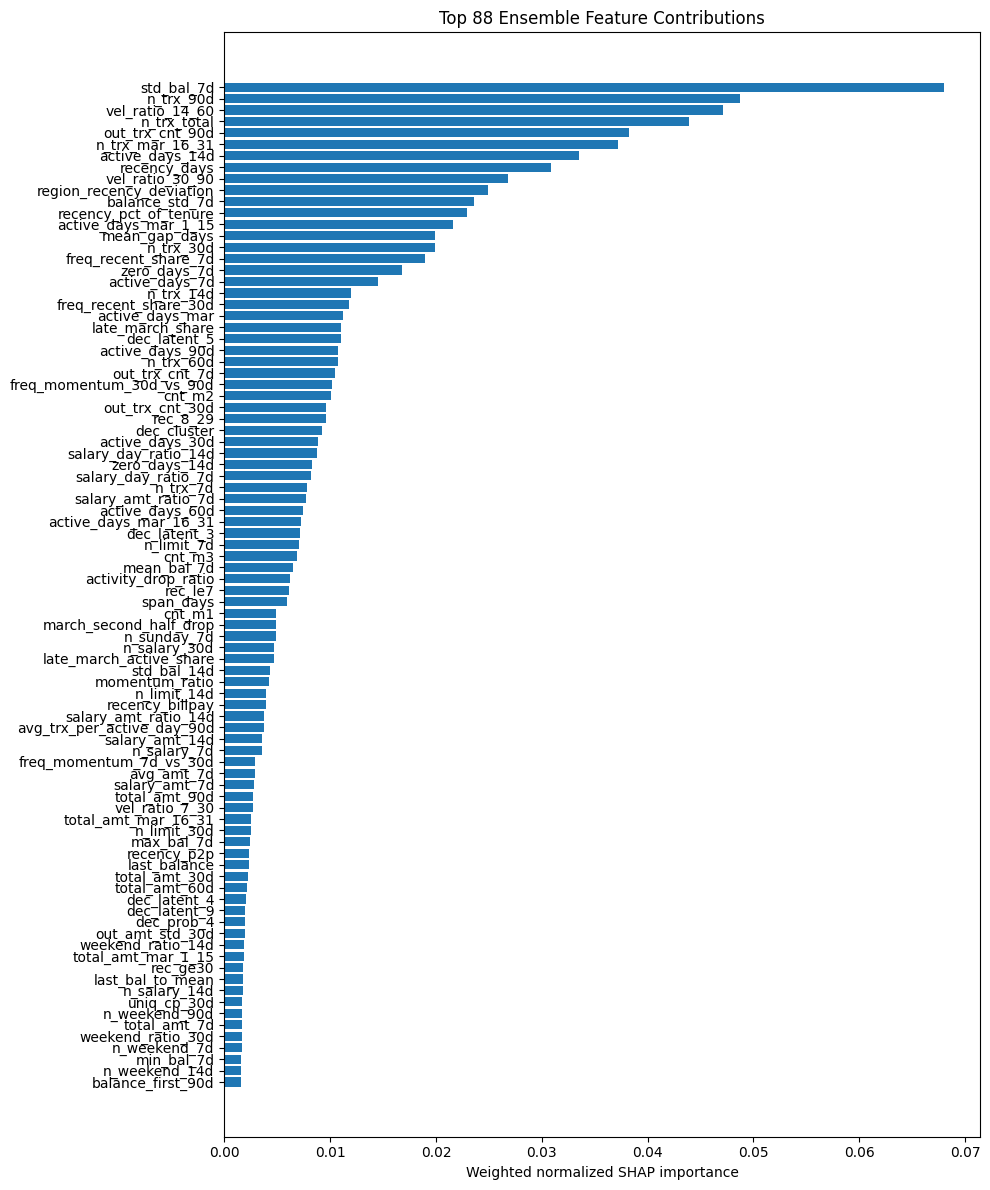

In [29]:
top_n = 88

plot_df = ensemble_shap_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 12))
plt.barh(
    plot_df["feature"],
    plot_df["ensemble_weighted_normalized_importance"]
)
plt.xlabel("Weighted normalized SHAP importance")
plt.title(f"Top {top_n} Ensemble Feature Contributions")
plt.tight_layout()
plt.savefig(
    "/kaggle/working/explainability/ensemble_shap_importance.png",
    dpi=160,
    bbox_inches="tight"
)
plt.show()

In [30]:
model_agreement = ensemble_shap_importance[
    [
        "feature",
        "ensemble_weighted_normalized_importance",
        "ensemble_raw_weighted_shap",
        "lgb_mean_abs_shap",
        "xgb_mean_abs_shap",
        "cat_mean_abs_shap",
    ]
].copy()

model_agreement.head(50)

,feature,ensemble_weighted_normalized_importance,ensemble_raw_weighted_shap,lgb_mean_abs_shap,xgb_mean_abs_shap,cat_mean_abs_shap
0,std_bal_7d,0.067986,0.329092,0.178896,0.248356,0.345780
1,n_trx_90d,0.048732,0.240672,0.070396,0.043864,0.259592
2,vel_ratio_14_60,0.047079,0.228872,0.112024,0.125483,0.241855
3,n_trx_total,0.043933,0.211320,0.131869,0.045175,0.220148
4,out_trx_cnt_90d,0.038198,0.190971,0.027008,0.134513,0.209189
5,n_trx_mar_16_31,0.037244,0.154629,0.408618,0.667339,0.126408
6,active_days_14d,0.033496,0.168725,0.008440,0.014878,0.186535
7,recency_days,0.030825,0.136151,0.239220,0.325010,0.124699
8,vel_ratio_30_90,0.026761,0.133444,0.023140,0.044112,0.145699
9,region_recency_deviation,0.024916,0.123206,0.034108,0.050553,0.133106


In [ ]:
ensemble_shap_importance.to_csv(
    "/kaggle/working/explainability/ensemble_shap_importance.csv",
    index=False
)

model_agreement.to_csv(
    "/kaggle/working/explainability/ensemble_model_agreement.csv",
    index=False
)

print("Saved:")
print("/kaggle/working/explainability/ensemble_shap_importance.csv")
print("/kaggle/working/explainability/ensemble_model_agreement.csv")
print("/kaggle/working/explainability/ensemble_shap_importance.png")

## 8 · Freeze and export

`TOP88_FEATURES` is the ranking's top 88 in rank order, which is also the CSV column order. The export uses this list and reports any divergence from the ranking computed above rather than applying it.

Column order forms part of the contract with `data_loader.py`; editing the list changes every model's input.

In [ ]:
# The frozen XMV-Net feature list: the top 88 of the SHAP ranking above, in rank order
# (= CSV column order). The export uses THIS list so the dataset cannot drift between runs.
TOP88_FEATURES = [
    "std_bal_7d", "n_trx_90d", "vel_ratio_14_60",
    "n_trx_total", "out_trx_cnt_90d", "n_trx_mar_16_31",
    "active_days_14d", "recency_days", "vel_ratio_30_90",
    "region_recency_deviation", "balance_std_7d", "recency_pct_of_tenure",
    "active_days_mar_1_15", "mean_gap_days", "n_trx_30d",
    "freq_recent_share_7d", "zero_days_7d", "active_days_7d",
    "n_trx_14d", "freq_recent_share_30d", "active_days_mar",
    "late_march_share", "dec_latent_5", "active_days_90d",
    "n_trx_60d", "out_trx_cnt_7d", "freq_momentum_30d_vs_90d",
    "cnt_m2", "out_trx_cnt_30d", "rec_8_29",
    "dec_cluster", "active_days_30d", "salary_day_ratio_14d",
    "zero_days_14d", "salary_day_ratio_7d", "n_trx_7d",
    "salary_amt_ratio_7d", "active_days_60d", "active_days_mar_16_31",
    "dec_latent_3", "n_limit_7d", "cnt_m3",
    "mean_bal_7d", "activity_drop_ratio", "rec_le7",
    "span_days", "cnt_m1", "march_second_half_drop",
    "n_sunday_7d", "n_salary_30d", "late_march_active_share",
    "std_bal_14d", "momentum_ratio", "n_limit_14d",
    "recency_billpay", "salary_amt_ratio_14d", "avg_trx_per_active_day_90d",
    "salary_amt_14d", "n_salary_7d", "freq_momentum_7d_vs_30d",
    "avg_amt_7d", "salary_amt_7d", "total_amt_90d",
    "vel_ratio_7_30", "total_amt_mar_16_31", "n_limit_30d",
    "max_bal_7d", "recency_p2p", "last_balance",
    "total_amt_30d", "total_amt_60d", "dec_latent_4",
    "dec_latent_9", "dec_prob_4", "out_amt_std_30d",
    "weekend_ratio_14d", "total_amt_mar_1_15", "rec_ge30",
    "last_bal_to_mean", "n_salary_14d", "uniq_cp_30d",
    "n_weekend_90d", "total_amt_7d", "weekend_ratio_30d",
    "n_weekend_7d", "min_bal_7d", "n_weekend_14d",
    "balance_first_90d",
]

assert len(TOP88_FEATURES) == len(set(TOP88_FEATURES)) == 88

recomputed = ensemble_shap_importance.head(88)["feature"].tolist()
if recomputed == TOP88_FEATURES:
    print("this run's SHAP ranking reproduces the frozen 88 exactly")
else:
    entered = sorted(set(recomputed) - set(TOP88_FEATURES))
    left = sorted(set(TOP88_FEATURES) - set(recomputed))
    print("WARNING: this run's SHAP ranking differs from the frozen list")
    print("  entered the top 88:", entered)
    print("  left the top 88:   ", left)
    print("  rank order changed:", recomputed != TOP88_FEATURES)
    print("  the export below still uses TOP88_FEATURES -- the dataset stays frozen")

In [ ]:
# Export the frozen XMV-Net dataset: train (with CHURN) and test (no label)

top_features = list(TOP88_FEATURES)

# ============================================================
# 1. Prepare feature dataframe
# ============================================================

export_df = features.reset_index().copy()

if "index" in export_df.columns and "ACCOUNT_ID" not in export_df.columns:
    export_df = export_df.rename(columns={"index": "ACCOUNT_ID"})

export_df["ACCOUNT_ID"] = export_df["ACCOUNT_ID"].astype(str)


# ============================================================
# 2. Prepare training labels
# ============================================================

labels_df = train_labels.to_pandas().copy()

labels_df["ACCOUNT_ID"] = labels_df["ACCOUNT_ID"].astype(str)

labels_df = labels_df[["ACCOUNT_ID", "CHURN"]]


# ============================================================
# 3. Merge labels onto features
# ============================================================

merged_df = export_df.merge(
    labels_df,
    on="ACCOUNT_ID",
    how="left"
)


# ============================================================
# 4. Columns to keep
# ============================================================

original_attrs = [
    "ACCOUNT_ID",
    "ACCOUNT_TYPE",
    "GENDER",
    "REGION",
    "ACCOUNT_OPEN_DATE"
]

missing = [c for c in top_features if c not in merged_df.columns]
assert not missing, f"frozen features missing from the engineered table: {missing}"
keep_feature_cols = list(top_features)

base_cols = [
    c for c in original_attrs
    if c in merged_df.columns
]

keep_cols = base_cols + keep_feature_cols


# ============================================================
# 5. TRAINING DATA
#    Accounts that have a churn label
# ============================================================

train_export = merged_df[
    merged_df["CHURN"].notna()
].copy()

train_export["CHURN"] = train_export["CHURN"].astype(int)

train_export = train_export[
    keep_cols + ["CHURN"]
]


# ============================================================
# 6. TEST DATA
#    Accounts without a churn label
# ============================================================

test_export = merged_df[
    merged_df["CHURN"].isna()
].copy()

test_export = test_export[
    keep_cols
]


# ============================================================
# 7. Save both CSVs
# ============================================================

train_path = "/kaggle/working/account_features_train_top88.csv"
test_path = "/kaggle/working/account_features_test_top88.csv"

train_export.to_csv(train_path, index=False)
test_export.to_csv(test_path, index=False)


# ============================================================
# 8. Verify
# ============================================================

print("TRAIN CSV")
print("Path:", train_path)
print("Shape:", train_export.shape)
print("Churn distribution:")
print(train_export["CHURN"].value_counts())

print("\nTEST CSV")
print("Path:", test_path)
print("Shape:", test_export.shape)

print("\nColumns in train:", len(train_export.columns))
print("Columns in test:", len(test_export.columns))
print("Feature count:", len(keep_feature_cols))

assert list(train_export.columns) == ["ACCOUNT_ID", "GENDER", "REGION"] + TOP88_FEATURES + ["CHURN"]
assert list(test_export.columns) == ["ACCOUNT_ID", "GENDER", "REGION"] + TOP88_FEATURES
assert train_export.shape == (595_000, 92) and test_export.shape == (255_000, 91)
print("export layout verified")